<a href="https://colab.research.google.com/github/Jayesh-m/collage/blob/main/kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving customer_segmentation_data.csv to customer_segmentation_data.csv


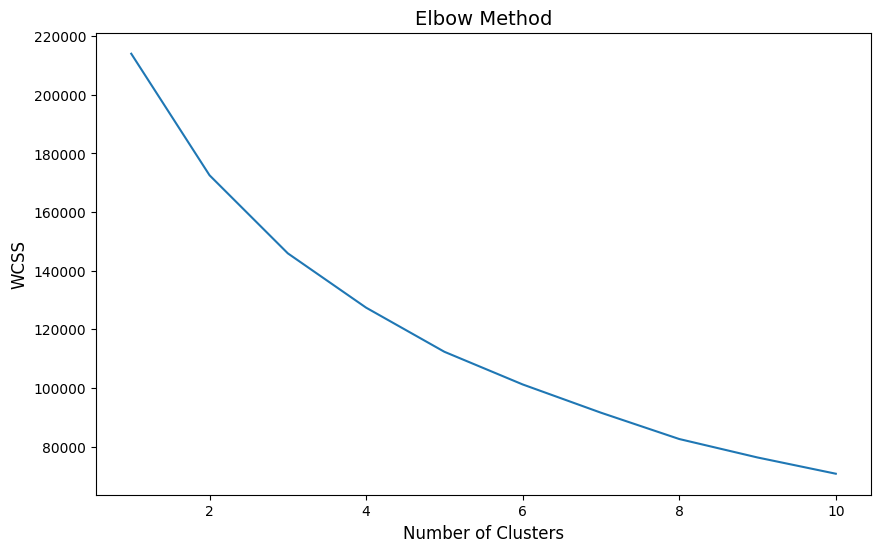


✅ Silhouette Score: 0.1894

📊 Cluster Statistics:
           Age  Income Level  Coverage Amount  Premium Amount
Cluster                                                      
0        44.39     118945.34        470700.62         3712.22
1        43.99      51868.31        501186.55         3863.46
2        44.05      79382.25        504932.31         1500.15

👥 Cluster Sizes:
Cluster
0    17303
1    18296
2    17904
Name: count, dtype: int64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from google.colab import files

# Upload
uploaded = files.upload()
df = pd.read_csv("customer_segmentation_data.csv")

# ── Select ONLY numerical columns ──
numerical_cols = ['Age', 'Income Level', 'Coverage Amount', 'Premium Amount']
df_num = df[numerical_cols].copy()

# Clean
df_num = df_num.dropna()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss)
plt.title("Elbow Method", fontsize=14)
plt.xlabel("Number of Clusters", fontsize=12)
plt.ylabel("WCSS", fontsize=12)
plt.show()

# KMeans (adjust K based on elbow)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

df_num['Cluster'] = labels

# Evaluate
score = silhouette_score(X_scaled, labels)
print(f"\n✅ Silhouette Score: {score:.4f}")

print("\n📊 Cluster Statistics:")
print(df_num.groupby('Cluster').mean().round(2))

print("\n👥 Cluster Sizes:")
print(df_num['Cluster'].value_counts().sort_index())